# Übung Simulation von Energiesystemen 
## PyPSA 04

### In einem Zukunftsszenario  gestalten Sie die Energieversorgung einer kleinen Kommune. Dafür haben Sie eine 4.5 MW Enercon Windturbine bauen lassen und sind zudem ans öffentliche Stromnetz angeschlossen und heizen mit einem großen Gaskessel. Sie haben bei der Ausschreibung für die Windturbine einen Zuschlagspreis von 6ct/kWh erhalten. Um die Energieversorgung nachhaltiger zu gestalten überlegen Sie eine Sektorenkopplung mittels Wasserstoff durchzuführen. Dafür möchten Sie einen Elektrolyseur, einen Wasserstoffspeicher, einen Wasserstoffkessel zum Heizen, sowie eine Brennstoffzelle zur Rückverstromung installieren. Die bei der Rückverstromung des Wasserstoffs durch die Brennstoffzelle entstehende Abwärme soll zudem auch genutzt werden. <br>

### Simulieren Sie das System um zu sehen ob die Wasserstoffintegration wirtschaftlich wäre und in welcher Größenordnung die Leistung der beteiligten Komponenten maximal benötigt werden würde.

<br>

### Führen Sie eine Sensitivitätsanalyse bezüglich der CO2 Emissionen des Systems durch. Diese sollen vom Emissionswert der Simulation ohne Beschränkung dabei Schrittweise um 10 Prozentpunkte auf schlussendlich 0 gesetzt werden.


Importieren Sie zunächst die notwendigen Bibliotheken

In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Sie erhalten hier die Auswertungsfunktion

In [2]:
def auswertungsfunktion (network,sensitivity_variable = 0):
    """  
    The function evaluates a Pypsa network regarding the optimal power and capacity of its components,
    the resulting CO2 emissions, investments costs and running costs. 

    
    Input:
    
    Network (pypsa object): a pypsa network

    Sensitivity variable (str, float or int): It can be defined in case of a sensitivity analysis of the network 
    otherwise it's set to 0

    Output: 
    Results (pandas DataFrame): Power and Capacity, greenhouse gas emissions and costs in a single DataFrame
   
    """
    
    #Function for CO2 emissions
    df1 = network.carriers
    df2 = network.generators.carrier
    CO2 = round((network.generators_t.p.sum()/network.generators.efficiency  * 
    pd.merge(df1, df2, left_index = True, right_on='carrier')['co2_emissions']).sum()) 
    
    #Function for investment costs
    total_invest      = round(network.statistics.capex().sum())

    #Function for running costs
    running_costs     = round(network.statistics.opex().sum())
    
    #Function for reward through infeed
    wind_reward    = round(network.generators_t.p['grid_infeed'].sum() * network.generators.marginal_cost['grid_infeed'] * -1)
    
    #Function for effective costs per year
    effective_costs = total_invest + running_costs 
    
    #Function for optimal component sizes
    links_opt      = [list(network.links.p_nom_opt.values)]
    generators_opt = [list(network.generators.p_nom_opt.values)]
    stores_opt     = [list(network.stores.e_nom_opt.values)]
    
    #Column names
    links_opt_names      = list(network.links.index)
    generators_opt_names = list(network.generators.index)
    stores_opt_names     = list(network.stores.index)

            
    results = pd.concat([pd.DataFrame(data = effective_costs, index = [sensitivity_variable], columns = ['effective_costs €/a']),
                        pd.DataFrame(data = total_invest, index = [sensitivity_variable], columns = ['total_invest']),
                        pd.DataFrame(data = running_costs, index =[sensitivity_variable], columns = ['running_costs €/a']),
                        pd.DataFrame(data = wind_reward, index = [sensitivity_variable], columns = ['wind_reward €/a']),
                        pd.DataFrame(data = CO2, index = [sensitivity_variable], columns = ['CO2_emissions kg/a']),
                        pd.DataFrame(data = links_opt, index = [sensitivity_variable], columns = links_opt_names),
                        pd.DataFrame(data = generators_opt, index = [sensitivity_variable], columns = generators_opt_names),
                        pd.DataFrame(data = stores_opt, index = [sensitivity_variable], columns = stores_opt_names)], 
                        axis = 1)
    
    
    return results  

Skizze des Netzwerks

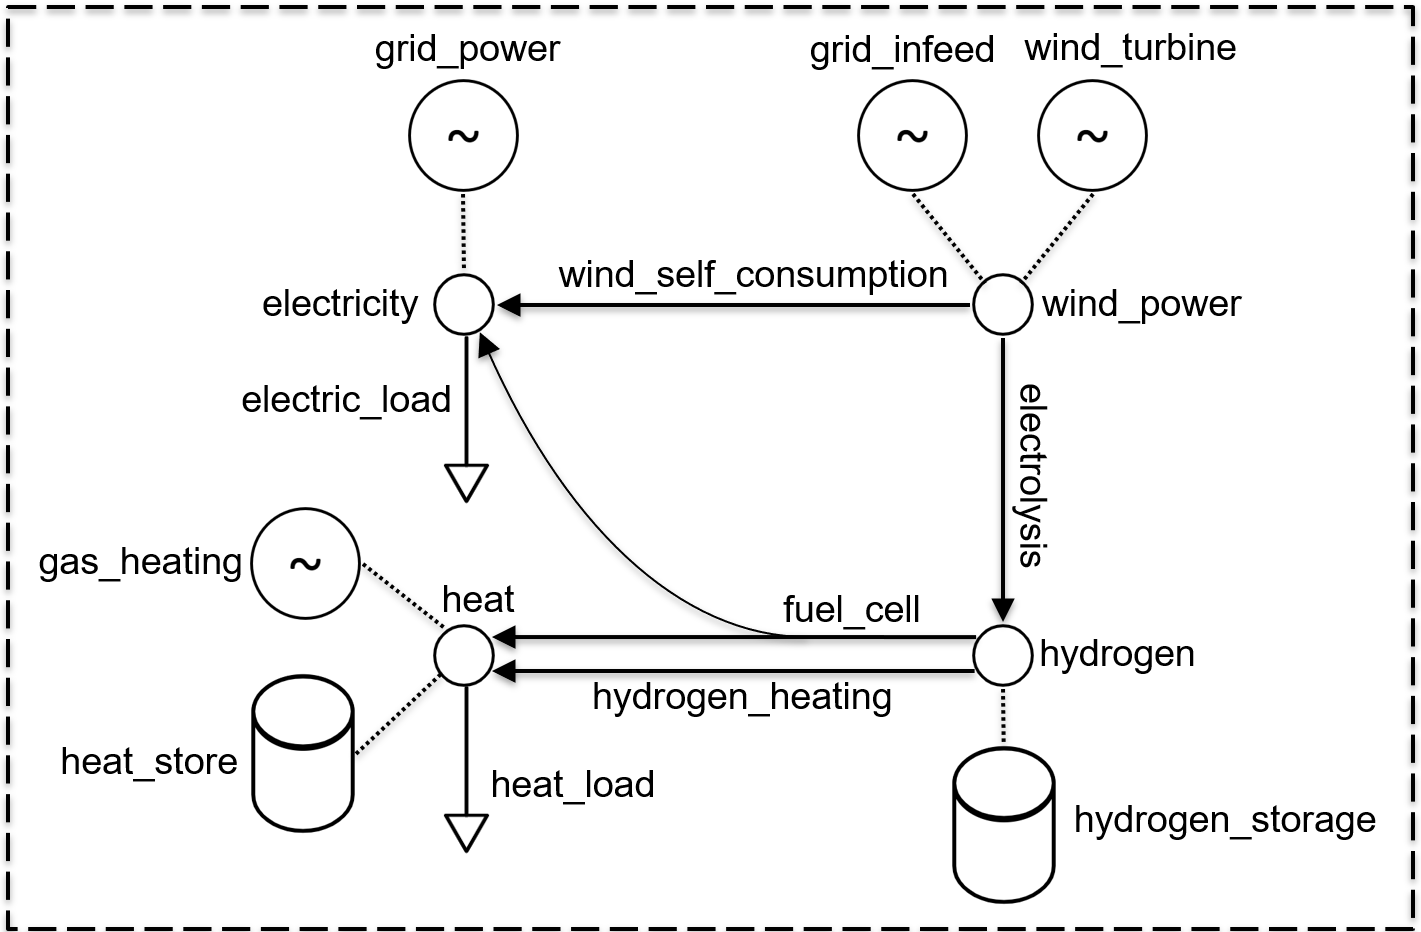

 Der Lastgang der Windturbine, die Heizlast, sowie die elektrische Last sind in der Datei "Input_data" gespeichert, lesen Sie diese mit pandas ein. (Tipp: pd.read_csv funktioniert genauso mit _excel für xlsx Dateien)

<Axes: >

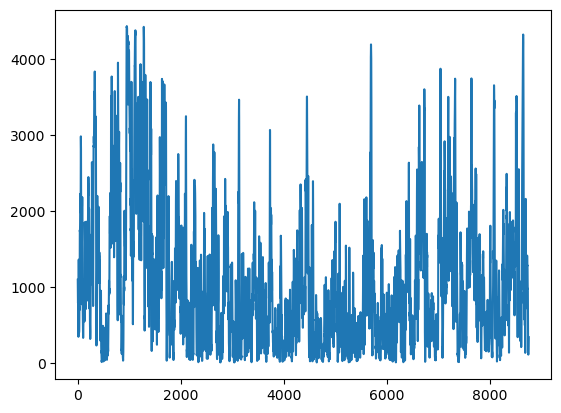

In [3]:
df_data = pd.read_excel('Input_data.xlsx')
df_data['wind_infeed'].plot()

In [4]:
wind_p_max_pu = df_data['wind_infeed']/4500
electric_load = df_data['electric_load_kW']
heat_data = df_data['Heizlast_kW']
max_electrical_load = electric_load.max()

Folgende technische/finanzielle Angaben sind Ihnen bekannt: <br> 
Ergänzen Sie die nötigen Angaben im darunterstehenden Feld

In [5]:
#marginal costs
electricity_rate =   0.4 #€/kWh
gas_rate         =  0.14 #€/kWh
grid_infeed = -0.06  #€ / kWh

#efficiencies
efficiency_electrolysis     = 0.65  #decimal
efficiency_fuel_cell        = 0.7   #decimal
fuel_cell_heat              = 0.25  #decimal
efficiency_hydrogen_heating = 0.95  #decimal
efficiency_gas_heating      = 0.95  #decimal
storage_loss_heat           = 0.005 #decimal



#co2 emissions
co2_emissions_germany_electricity  = 0.375 #kg/kWh
co2_emissions_natural_gas          = 0.274 #kg/kWh

#capital costs
capital_cost_electrolysis     = 200  #€/kW  as anuity
capital_cost_fuel_cell        = 1000 #€/kW  as anuity
capital_cost_hydrogen_storage = 50   #€/kWh as anuity
capital_cost_hydrogen_heating = 10   #€/kW  as anuity
capital_cost_gas_heating      = 7    #€/kW  as anuity
capital_cost_wind             = 150  #€/kW  as anuity
capital_cost_heat_store       = 10   #€/kWh as anuity

In [6]:
wind_p_nom_max = 9000
wind_p_nom_min = 4500


Implementieren Sie das System

In [8]:
network = pypsa.Network()
network.set_snapshots(range(8760))


#Carriers
network.add('Carrier', name = 'german_electricity', 
            co2_emissions = co2_emissions_germany_electricity)
network.add('Carrier', name = 'natural_gas', 
            co2_emissions = co2_emissions_natural_gas)

#Buses
network.add('Bus', name = 'electricity')
network.add('Bus', name = 'wind_power')
network.add('Bus', name = 'hydrogen')
network.add('Bus', name = 'heat')

# Loads
network.add('Load', bus = 'electricity', name = 'electrical_load', p_set = electric_load)
network.add('Load', name = 'thermal_load', bus = 'heat', p_set = heat_data)


# Generators
network.add('Generator', name = 'grid_power', bus = 'electricity', marginal_cost = electricity_rate, 
            p_nom = np.inf, carrier = 'german_electricity')
network.add('Generator', name = 'wind_turbine', bus = 'wind_power', p_max_pu = wind_p_max_pu, p_nom_extendable = True, 
            p_nom_min = wind_p_nom_min, p_nom_max = wind_p_nom_max, capital_cost = capital_cost_wind,
           p_nom_mod = wind_p_nom_min)
network.add('Generator', name = 'grid_infeed', bus = 'wind_power', marginal_cost = grid_infeed, p_nom = wind_p_nom_max,
            sign = -1)
network.add('Generator', name = 'gas_heating', bus = 'heat',
            marginal_cost = gas_rate/efficiency_gas_heating, 
            capital_cost = capital_cost_gas_heating, p_nom_extendable = True,
            efficiency = efficiency_gas_heating, carrier = 'natural_gas')


#Links
network.add('Link', name = 'wind_self_consumption', bus0 = 'wind_power', bus1 = 'electricity', p_nom = wind_p_nom_max)
network.add('Link', name = 'electrolysis', bus0 = 'wind_power', bus1= 'hydrogen', p_nom_extendable = True,
            capital_cost = capital_cost_electrolysis, efficiency = efficiency_electrolysis)
network.add('Link', name = 'hydrogen_heating', bus0 = 'hydrogen', bus1 ='heat',
            p_nom_extendable = True,  capital_cost = capital_cost_hydrogen_heating, efficiency = efficiency_hydrogen_heating)
network.add('Link', name = 'fuel_cell', bus0 = 'hydrogen', bus1 = 'heat', bus2 = 'electricity', efficiency = fuel_cell_heat,
            efficiency2 = efficiency_fuel_cell, capital_cost = capital_cost_fuel_cell, p_nom_extendable = True)


#Stores
network.add('Store', name = 'hydrogen_storage', bus = 'hydrogen', e_nom_extendable = True, 
            capital_cost = capital_cost_hydrogen_storage, e_cyclic = True)
network.add('Store', name = 'heat_store', bus = 'heat', 
           e_nom_extendable = True, capital_cost = capital_cost_heat_store,
           standing_loss = storage_loss_heat, e_cyclic = True)

#Global Constraint
network.add('GlobalConstraint', name = 'co2-limit', 
           sense = '<=', carrier_attribute = 'co2_emissions',
           constant = 1000000)

Index(['co2-limit'], dtype='object')

Optimieren Sie das Netzwerk mit der Methode .optimize(solver_name = 'gurobi', threads = 1, method = 2)

In [9]:
network.optimize(solver_name = 'gurobi', threads = 1, method = 2)

Index(['hydrogen_storage', 'heat_store'], dtype='object', name='Store')
Index(['electricity', 'wind_power', 'hydrogen', 'heat'], dtype='object', name='Bus')
Index(['wind_self_consumption', 'electrolysis', 'hydrogen_heating',
       'fuel_cell'],
      dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 1
 - method: 2
INFO:linopy.io:Writing objective.
Writing integer variables.: 100%|██████████| 1/1 [00:00<00:00, 613.11it/s]
INFO:linopy.io: Writing time: 3.92s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Optimal solution found (tolerance 1.00e-04)


INFO:gurobipy:Optimal solution found (tolerance 1.00e-04)


Best objective 1.848398836839e+06, best bound 1.848398836839e+06, gap 0.0000%


INFO:gurobipy:Best objective 1.848398836839e+06, best bound 1.848398836839e+06, gap 0.0000%
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105128 primals, 0 duals
Objective: 1.85e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


('ok', 'optimal')

Geben Sie mit der Auswertungsfunktion die Simulationsergebnisse aus

In [10]:
auswertungsfunktion(network)

,effective_costs €/a,total_invest,running_costs €/a,wind_reward €/a,CO2_emissions kg/a,wind_self_consumption,electrolysis,hydrogen_heating,fuel_cell,grid_power,wind_turbine,grid_infeed,gas_heating,hydrogen_storage,heat_store
0,1848399,1745370,103029,524909,1000000,9000.0,1775.946693,1154.36535,0.0,inf,9000.0,9000.0,2084.520849,0.0,1404.491347


Schauen sie sich mit "network.generators_t.p.plot()" und network.links_t.p0.plot() an, wie die Last über das Jahr abgedeckt wird

In [11]:
network.stores.e_nom_opt

Store
hydrogen_storage       0.000000
heat_store          1404.491347
Name: e_nom_opt, dtype: float64

In [12]:
network.generators.p_nom_opt

Generator
grid_power              inf
wind_turbine    9000.000000
grid_infeed     9000.000000
gas_heating     2084.520849
Name: p_nom_opt, dtype: float64

Sehen Sie nach ob die Windenergieanlage Strom in das Netz eingespeist hat und geben Sie gegebenenfalls die Erlöse aus

Führen Sie die Sensitivitätsanalyse für die CO2 Emissionen aus

In [13]:
# Berechnung der CO2-Emissionen ohne Begrenzung
standard_co2_limit = float(network.global_constraints['constant'])
network.global_constraints.loc['co2-limit', 'constant'] = np.inf
network.optimize(solver_name = 'gurobi', threads = 1, method = 2)
results = auswertungsfunktion(network, 100)
standard_co2_emissions = float(results['CO2_emissions kg/a'])

# Rename index column
results.index.name = 'CO2 in % of the standard emissions'

#Sensitivity analysis for variable co2 limits + filling of the DF with different results
for co2_limit in np.flip(np.arange(0, 1, 0.1)):
    print (co2_limit)
    network.global_constraints.loc['co2-limit', 'constant'] = co2_limit * standard_co2_emissions
    
    network.optimize(solver_name = 'gurobi', threads = 1, method = 2)
    results = pd.concat([results, auswertungsfunktion(network, co2_limit*100)])
# Change co2-limit back to standard
network.global_constraints.loc['co2-limit', 'constant'] = standard_co2_limit

/tmp/ipykernel_754/4247364114.py:2: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

Index(['hydrogen_storage', 'heat_store'], dtype='object', name='Store')
Index(['electricity', 'wind_power', 'hydrogen', 'heat'], dtype='object', name='Bus')
Index(['wind_self_consumption', 'electrolysis', 'hydrogen_heating',
       'fuel_cell'],
      dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 1
 - method: 2
INFO:linopy.io:Writing objective.
Writing integer variables.: 100%|██████████| 1/1 [00:00<00:00, 692.02it/s]
INFO:linopy.io: Writing time: 3.51s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

INFO:gurobipy:


Optimal solution found (tolerance 1.00e-04)


INFO:gurobipy:Optimal solution found (tolerance 1.00e-04)


Best objective 4.413501897681e+07, best bound 4.413501897681e+07, gap 0.0000%


INFO:gurobipy:Best objective 4.413501897681e+07, best bound 4.413501897681e+07, gap 0.0000%
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105128 primals, 0 duals
Objective: 4.41e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


Schauen Sie sich die numerischen Werte der Ergebnisse an

In [14]:
results

,effective_costs €/a,total_invest,running_costs €/a,wind_reward €/a,CO2_emissions kg/a,wind_self_consumption,electrolysis,hydrogen_heating,fuel_cell,grid_power,wind_turbine,grid_infeed,gas_heating,hydrogen_storage,heat_store
100.0,1646944,1368067,278877,866391,2012519,9000.0,0.000000,0.000000,0.000000,inf,9000.0,9000.0,2580.961782,0.000000,0.000000
90.0,1660840,1416946,243894,798580,1811267,9000.0,241.765790,157.147763,0.000000,inf,9000.0,9000.0,2431.670913,0.000000,0.000995
80.0,1680802,1471825,208977,730753,1610015,9000.0,508.444458,330.488898,0.000000,inf,9000.0,9000.0,2400.820622,0.000000,2.516614
70.0,1712226,1538329,173897,662963,1408763,9000.0,828.783277,538.709130,0.000000,inf,9000.0,9000.0,2378.282245,0.000000,53.730398
60.0,1763827,1624892,138935,595099,1207511,9000.0,1230.577646,799.875470,0.000000,inf,9000.0,9000.0,2238.129701,0.000000,511.049185
50.0,1844724,1740612,104112,527024,1006259,9000.0,1752.906437,1139.389184,0.000000,inf,9000.0,9000.0,2084.520849,0.000000,1404.491347
40.0,2033066,1960510,72556,455735,805008,9000.0,2506.813100,1629.428515,0.000000,inf,9000.0,9000.0,1690.629586,0.000000,8101.912159
30.0,2852380,2813722,38658,366101,603756,9000.0,3796.157911,2467.502642,129.383746,inf,9000.0,9000.0,1977.480789,1636.064768,45478.648542
20.0,5719501,5770819,-51318,292951,402504,9000.0,5720.975048,3682.642859,792.256426,inf,9000.0,9000.0,1809.009216,28520.779034,100883.957820
10.0,19206742,19343352,-136610,246948,201252,9000.0,7149.384890,2763.734852,1973.497814,inf,9000.0,9000.0,493.920552,271916.758655,96304.419463


Stellen Sie die Ergebnisse grafisch dar anschaulich dar und achten Sie auf eine passende Achsenbezeichnung. <br>(Hinweis: Nutzen Sie dafür die Bibliothek matplotlib.pyplot)

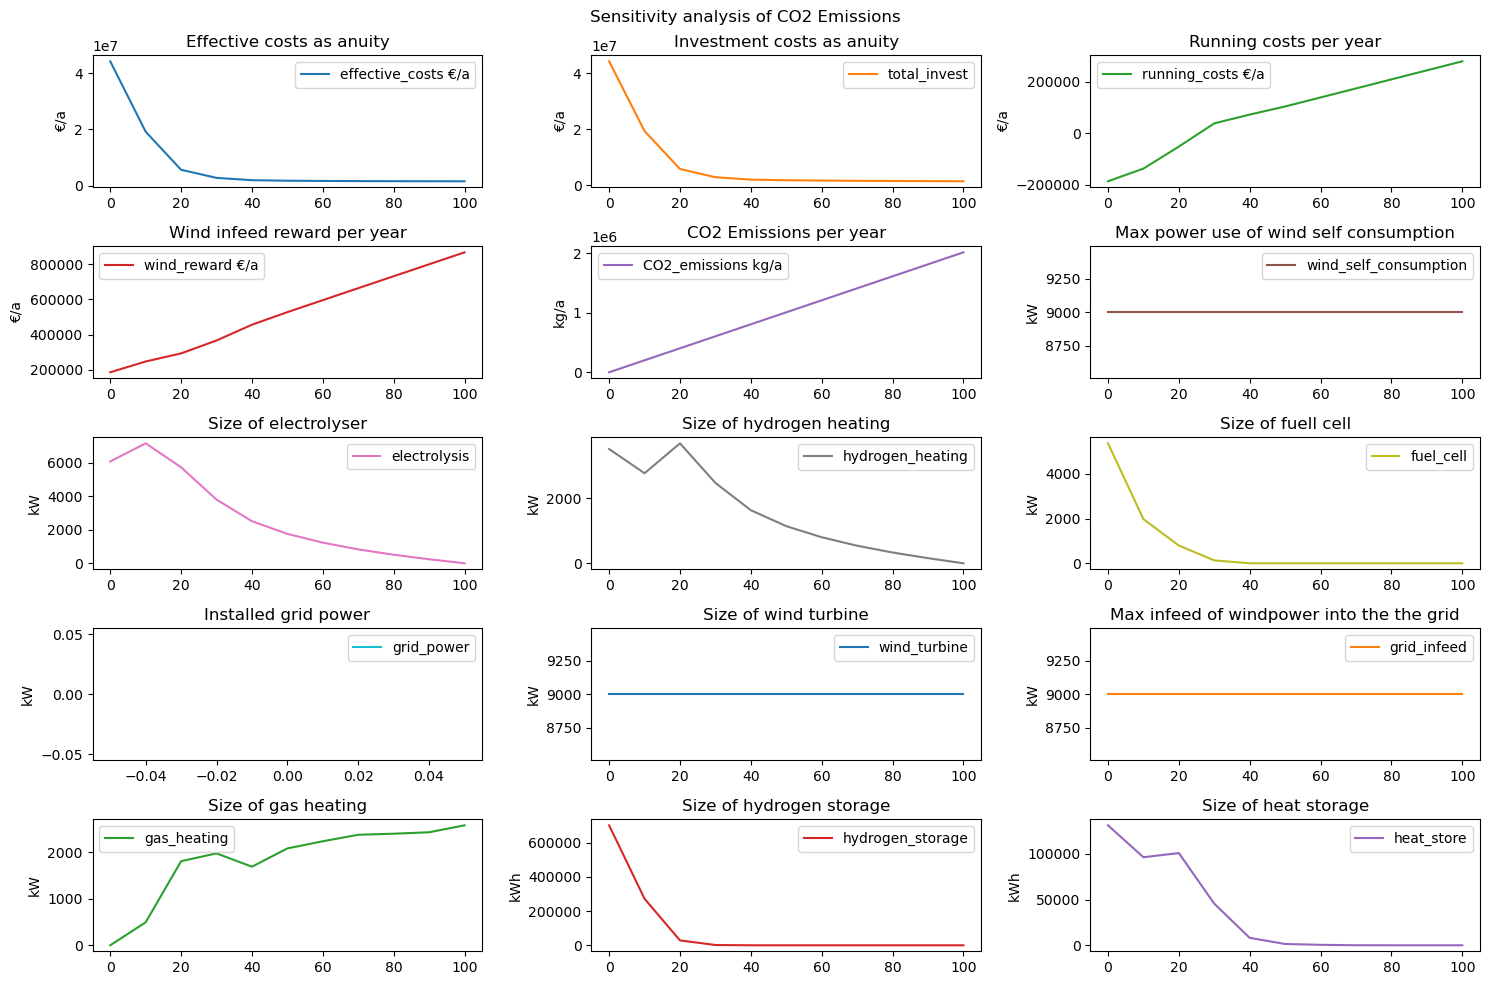

In [15]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize = (15,10))
results.plot(subplots=True, ax=axes)

axes[0,0].set_ylabel('€/a') 
axes[0,1].set_ylabel('€/a')
axes[0,2].set_ylabel('€/a')
axes[1,0].set_ylabel('€/a')
axes[1,1].set_ylabel('kg/a')
axes[1,2].set_ylabel('kW')
axes[2,0].set_ylabel('kW')
axes[2,1].set_ylabel('kW')
axes[2,2].set_ylabel('kW')
axes[3,0].set_ylabel('kW')
axes[3,1].set_ylabel('kW')
axes[3,2].set_ylabel('kW')
axes[4,0].set_ylabel('kW')
axes[4,1].set_ylabel('kWh')
axes[4,2].set_ylabel('kWh')

axes[0,0].set_title('Effective costs as anuity')
axes[0,1].set_title('Investment costs as anuity')
axes[0,2].set_title('Running costs per year')
axes[1,0].set_title('Wind infeed reward per year')
axes[1,1].set_title('CO2 Emissions per year')
axes[1,2].set_title('Max power use of wind self consumption')
axes[2,0].set_title('Size of electrolyser')
axes[2,1].set_title('Size of hydrogen heating')
axes[2,2].set_title('Size of fuell cell')
axes[3,0].set_title('Installed grid power')
axes[3,1].set_title('Size of wind turbine')
axes[3,2].set_title('Max infeed of windpower into the the grid')
axes[4,0].set_title('Size of gas heating')
axes[4,1].set_title('Size of hydrogen storage')
axes[4,2].set_title('Size of heat storage')

fig.suptitle('Sensitivity analysis of CO2 Emissions')
fig.tight_layout()